## Multiply weight and biases by fan_in

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:

df = pd.read_csv("ushape.csv")

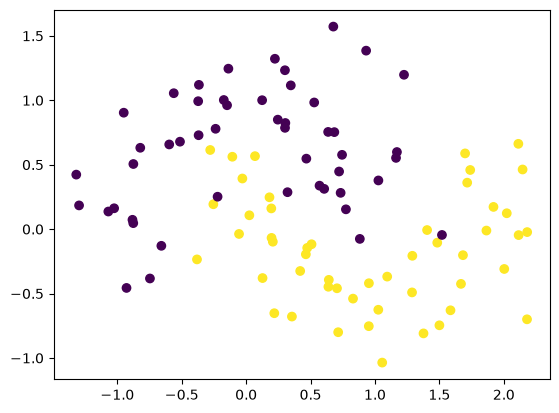

In [3]:
plt.scatter(
    x=df['3.159499363321345566e-02'],
    y=df['9.869877579082642072e-01'],
    c=df['0.000000000000000000e+00']
)
plt.show()

In [ ]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [5]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [7]:
model = Sequential()

model.add(Dense(10,activation='tanh',input_dim=2))
model.add(Dense(10,activation='tanh'))
model.add(Dense(10,activation='tanh'))
model.add(Dense(10,activation='tanh'))
model.add(Dense(1,activation='sigmoid'))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.get_weights()

[array([[ 0.5362204 ,  0.6264666 , -0.00137955, -0.40376613,  0.616301  ,
         -0.5441096 , -0.61474615, -0.2648619 , -0.08416116,  0.3654483 ],
        [-0.07822943,  0.00436407,  0.30742615, -0.05565172, -0.6752416 ,
          0.0770542 , -0.48575523, -0.3559463 , -0.4365341 ,  0.55468136]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.09674114, -0.24199316,  0.33368576, -0.36533022, -0.22091079,
          0.12478602,  0.08218652, -0.28628275,  0.5302999 , -0.0644947 ],
        [ 0.17631143,  0.423047  , -0.12897906, -0.539689  ,  0.12850308,
          0.05515248, -0.1929233 ,  0.23251057, -0.49449706,  0.18740559],
        [ 0.14537638,  0.24101806,  0.02924865, -0.26285958,  0.14444685,
          0.00745052, -0.21835595,  0.04746127,  0.15901959, -0.4201091 ],
        [-0.47829628, -0.29515392,  0.32580447, -0.21110916,  0.22518253,
         -0.05670321,  0.33019334,  0.30982423, -0.40044498, -0.0469436 ],
        [ 0.43243

In [9]:
initial_weights = model.get_weights()

In [11]:
initial_weights[0] = np.random.randn(2,10)*np.sqrt(1/2)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)
initial_weights[4] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[5] = np.zeros(model.get_weights()[5].shape)
initial_weights[6] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[7] = np.zeros(model.get_weights()[7].shape)
initial_weights[8] = np.random.randn(10,1)*np.sqrt(1/10)
initial_weights[9] = np.zeros(model.get_weights()[9].shape)

In [12]:
model.set_weights(initial_weights)

In [14]:
model.get_weights()

[array([[ 0.39576042,  0.71497506,  0.5227947 ,  0.18397607,  0.05833544,
         -0.0683903 ,  0.2979519 , -0.4215991 , -1.2815055 , -0.7359648 ],
        [ 1.0329123 ,  0.6030396 , -1.374066  , -1.1006923 ,  0.91343045,
          0.02859132,  0.4198439 , -0.9111818 ,  0.8099871 ,  0.5380737 ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.25634715,  0.11720142, -0.32469928, -0.21909797, -0.11244705,
         -0.13951243, -0.05528982, -0.26839668, -0.5029995 ,  0.35492712],
        [ 0.00262768,  0.20926411,  0.67130864,  0.4061355 , -0.01272783,
         -0.01059678,  0.31555977,  0.08716434,  0.07292528, -0.41904137],
        [-0.24285306, -0.3003543 , -0.13403948,  0.14604907, -0.23129135,
          0.3707644 ,  0.13117047,  0.03317848,  0.0902648 ,  0.19625501],
        [ 0.4347639 ,  0.244514  , -0.12470768, -0.15688035,  0.29610986,
          0.14682558, -0.3678637 , -0.2010118 , -0.24523608, -0.10356991],
        [ 0.36145

In [15]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [16]:
history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.7089 - loss: 0.6675 - val_accuracy: 0.8500 - val_loss: 0.6393
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7975 - loss: 0.6502 - val_accuracy: 0.9000 - val_loss: 0.6211
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8354 - loss: 0.6346 - val_accuracy: 0.9000 - val_loss: 0.6040
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8481 - loss: 0.6195 - val_accuracy: 0.8500 - val_loss: 0.5884
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8101 - loss: 0.6070 - val_accuracy: 0.8500 - val_loss: 0.5731
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8101 - loss: 0.5936 - val_accuracy: 0.8500 - val_loss: 0.5581
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7975 - loss: 0.5819 - val_accuracy: 0.8500 - val_loss: 0.5434
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7975 - loss: 0.5697 - val_accuracy: 0.8500 - val_loss:

In [17]:
model.get_weights()

[array([[ 0.30977467,  0.71337   ,  0.56765556,  0.05868291,  0.01608186,
         -0.1431325 ,  0.24000584, -0.34882337, -1.5833029 , -0.6153838 ],
        [ 1.062994  ,  0.57981414, -1.3528787 , -1.0947214 ,  0.8795492 ,
          0.11443239,  0.3636935 , -0.9368588 ,  0.7772734 ,  0.6296433 ]],
       dtype=float32),
 array([-0.06396544,  0.09272068, -0.05222949, -0.01498449,  0.0888017 ,
         0.02301106,  0.02835835,  0.09315409,  0.17155378,  0.05051516],
       dtype=float32),
 array([[ 0.25566503,  0.00430064, -0.33056343, -0.15370378, -0.14775941,
         -0.13460617, -0.12930422, -0.33493802, -0.40442142,  0.3168256 ],
        [-0.08092162,  0.1440093 ,  0.7277442 ,  0.48511782,  0.0388514 ,
         -0.04533942,  0.25532752,  0.02635369,  0.20738493, -0.36051202],
        [-0.35570163, -0.3022871 , -0.05037875,  0.2556274 , -0.14399831,
          0.30544215,  0.20311703, -0.09883723,  0.1665712 ,  0.22999907],
        [ 0.3582855 ,  0.29815596, -0.06413551, -0.1038187 , 

<Axes: >

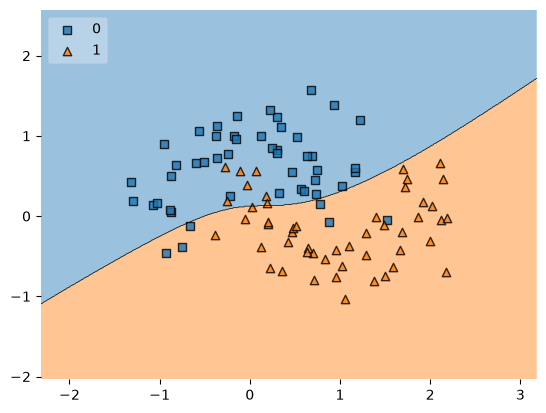

In [18]:
from mlxtend.plotting import plot_decision_regions

class KerasWrapper:

    def __init__(self, model):
        self.model = model

    def predict(self, X):
        pred = self.model.predict(X, verbose=0)
        return (pred > 0.5).astype(int).ravel()
    
wrapped_model = KerasWrapper(model)

plot_decision_regions(
    X,
    y.astype('int'),
    clf=wrapped_model,
    legend=2
)